# Análisis de datos
### Nancy Armua | Brian Talavera 

## Preparación de ambiente 

In [59]:
import pandas as pd
import numpy as np
from pandas.api.types import CategoricalDtype
import matplotlib.pyplot as plt
import seaborn as sns
from utils import plot_histograma, plot_histograma_estadisticos

### Fuente del dataset

Dataset recorridos Ecobicis 2023: https://data.buenosaires.gob.ar/dataset/bicicletas-publicas/resource/ff671909-6860-4398-8d0a-8f2389cb2780/download

Dataset ususarios Ecobicis 2023: https://data.buenosaires.gob.ar/dataset/bicicletas-publicas/resource/edb5ed27-8506-43f0-88ce-3e5c0aa1a406/download


#### 1. Cargar datos desde un archivo CSV a un df de Pandas

In [60]:
path = "./dataset/"

df_recorridos = pd.read_csv(path + "trips_2023.csv")
df_usuarios = pd.read_csv(path + "usuarios_ecobici_2023.csv")


/tmp/ipykernel_32819/392836254.py:4: DtypeWarning: Columns (0: edad_usuario) have mixed types. Specify dtype option on import or set low_memory=False.
  df_usuarios = pd.read_csv(path + "usuarios_ecobici_2023.csv")


** A revisar: para el dataset de usuarios, edar_usuario aparentemente contiene datos mixtos.

## Exploración y comprensión de los datos
### Primeras filas de cada dataset


In [61]:
# Mostrar las primeras 5 filas de cada dataset
df_recorridos.head(5)


,Unnamed: 0,Id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,género
0,1,17910696BAEcobici,"1,848",2023-04-24 10:30:10,358BAEcobici,249 - Balbín,2519 Conesa,-58.465586,-34.561486,2023-04-24 11:00:58,278BAEcobici,233 - MONROE,2519 Superi,-58.469813,-34.564122,861866BAEcobici,ICONIC,MALE
1,2,17600256BAEcobici,288,2023-03-22 17:40:55,444BAEcobici,061 - Ministerio de Economia,"Balcarce e Yrigoyen, Hipolito Av.",-58.370716,-34.608936,2023-03-22 17:45:43,3BAEcobici,003 - ADUANA,Moreno & Azopardo,-58.368174,-34.611102,217525BAEcobici,ICONIC,FEMALE
2,3,17255670BAEcobici,"1,103",2023-02-15 23:12:22,280BAEcobici,222 - SIMON BOLIVAR,"1701 Fernandez Moreno, Baldomero",-58.449379,-34.633528,2023-02-15 23:30:45,280BAEcobici,222 - SIMON BOLIVAR,"1701 Fernandez Moreno, Baldomero",-58.449379,-34.633528,954201BAEcobici,ICONIC,MALE
3,4,17996972BAEcobici,"1,165",2023-05-03 11:00:20,273BAEcobici,223 - GAINZA,"494 Gainza, Martin De, Gral.",-58.446751,-34.616758,2023-05-03 11:19:45,367BAEcobici,287 - Belaustegui,"Belaustegui, Luis, Dr. 2890",-58.477209,-34.616212,179414BAEcobici,ICONIC,MALE
4,5,17148836BAEcobici,378,2023-02-06 06:50:58,65BAEcobici,065 - Julián Álvarez,3822 Guemes,-58.415787,-34.587312,2023-02-06 06:57:16,14BAEcobici,014 - Pacifico,"Santa Fe Av. & Bullrich, Int. Av.",-58.426387,-34.577424,8098BAEcobici,ICONIC,MALE


In [62]:
df_usuarios.head(5)

,ID_usuario,genero_usuario,edad_usuario,fecha_alta,hora_alta,Customer.Has.Dni..Yes...No.
0,1083476,MALE,20,2023-12-31,19:24:57,Yes
1,1083080,FEMALE,18,2023-12-31,00:05:03,Yes
2,1083163,OTHER,27,2023-12-31,10:16:12,No
3,1083435,MALE,24,2023-12-31,17:42:11,Yes
4,1083376,OTHER,32,2023-12-31,16:16:15,No


#### Descripción del dataset de usuarios


| Variable | Descripción | Tipo |
| --- | --- | --- |
| `ID_usuario` | Identificador único del usuario | Categórica nominal |
| `genero_usuario` | Género autopercibido declarado por el usuario (`MALE`, `FEMALE`, `OTHER`) | Categórica nominal |
| `edad_usuario` | Edad del usuario en años | Cuantitativa discreta |
| `fecha_alta` | Fecha de alta del usuario en el sistema | Categórica / Cuantitativa |
| `hora_alta` | Hora de alta del usuario en el sistema | Cuantitativa continua |
| `Customer.Has.Dni..Yes...No.` | Indica si el usuario cuenta con DNI registrado (`Yes`/`No`) | Categórica nominal |


#### Descripción del dataset de recorridos

| Variable | Descripción | Tipo |
| --- | --- | --- |
| `Id_recorrido` | Identificador único del recorrido | Categórica nominal |
| `duracion_recorrido` | Duración del recorrido (en segundos) | Cuantitativa continua |
| `fecha_origen_recorrido` | Fecha y hora de inicio del recorrido | Categórica / Cuantitativa |
| `id_estacion_origen` | Identificador de la estación de origen | Categórica nominal |
| `nombre_estacion_origen` | Nombre de la estación de origen | Categórica nominal |
| `direccion_estacion_origen` | Dirección de la estación de origen | Categórica nominal |
| `long_estacion_origen` | Longitud geográfica de la estación de origen | Cuantitativa continua |
| `lat_estacion_origen` | Latitud geográfica de la estación de origen | Cuantitativa continua |
| `fecha_destino_recorrido` | Fecha y hora de finalización del recorrido | Categórica / Cuantitativa |
| `id_estacion_destino` | Identificador de la estación de destino | Categórica nominal |
| `nombre_estacion_destino` | Nombre de la estación de destino | Categórica nominal |
| `direccion_estacion_destino` | Dirección de la estación de destino | Categórica nominal |
| `long_estacion_destino` | Longitud geográfica de la estación de destino | Cuantitativa continua |
| `lat_estacion_destino` | Latitud geográfica de la estación de destino | Cuantitativa continua |
| `id_usuario` | Identificador del usuario que realizó el recorrido | Categórica nominal |
| `modelo_bicicleta` | Modelo de la bicicleta utilizada (`ICONIC`, `FIT`) | Categórica nominal |
| `género` | Género autopercibido del usuario (`MALE`, `FEMALE`, `OTHER`) | Categórica nominal |


### Definición del problema de ML que se quiere resolver

Predecir la duración de un recorrido, primero definir categorias de duración de recorrido, luego predecir la categoría a la que pertenece un recorrido dado.

### 2. Diagnóstico inicial: dimensiones, tipos de datos, duplicados y valores faltantes


In [63]:
for nombre, df in [("recorridos", df_recorridos), ("usuarios", df_usuarios)]:
    print(f"\n===== {nombre.upper()} =====")
    print("Dimensiones (filas, columnas):", df.shape)
    print("\nTipos de datos:")
    print(df.dtypes)
    print("\nDuplicados exactos:", df.duplicated().sum())
    print("\nValores nulos por columna:")
    print(df.isnull().sum())



===== RECORRIDOS =====
Dimensiones (filas, columnas): (2622331, 18)

Tipos de datos:
Unnamed: 0                      int64
Id_recorrido                      str
duracion_recorrido                str
fecha_origen_recorrido            str
id_estacion_origen                str
nombre_estacion_origen            str
direccion_estacion_origen         str
long_estacion_origen          float64
lat_estacion_origen           float64
fecha_destino_recorrido           str
id_estacion_destino               str
nombre_estacion_destino           str
direccion_estacion_destino        str
long_estacion_destino         float64
lat_estacion_destino          float64
id_usuario                        str
modelo_bicicleta                  str
género                            str
dtype: object

Duplicados exactos: 0

Valores nulos por columna:
Unnamed: 0                        0
Id_recorrido                      0
duracion_recorrido                0
fecha_origen_recorrido            0
id_estacion_origen   

#### Número de observaciones y de variables (consigna, punto 2)


In [64]:
for nombre, df in [("usuarios", df_usuarios), ("recorridos", df_recorridos)]:
    print(f"{nombre}: {df.shape[0]:,} observaciones y {df.shape[1]} variables")


usuarios: 136,066 observaciones y 6 variables
recorridos: 2,622,331 observaciones y 18 variables


### Inspeccionar y corregir tipos de datos

Como se vio en clase, Pandas no siempre asigna el dtype correcto al importar un CSV: hay que
revisar cada variable y asignar el tipo que le corresponde (numérica, categórica u fecha).


In [65]:
df_recorridos.info()

<class 'pandas.DataFrame'>
RangeIndex: 2622331 entries, 0 to 2622330
Data columns (total 18 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   Unnamed: 0                  int64  
 1   Id_recorrido                str    
 2   duracion_recorrido          str    
 3   fecha_origen_recorrido      str    
 4   id_estacion_origen          str    
 5   nombre_estacion_origen      str    
 6   direccion_estacion_origen   str    
 7   long_estacion_origen        float64
 8   lat_estacion_origen         float64
 9   fecha_destino_recorrido     str    
 10  id_estacion_destino         str    
 11  nombre_estacion_destino     str    
 12  direccion_estacion_destino  str    
 13  long_estacion_destino       float64
 14  lat_estacion_destino        float64
 15  id_usuario                  str    
 16  modelo_bicicleta            str    
 17  género                      str    
dtypes: float64(4), int64(1), str(13)
memory usage: 842.3 MB


In [66]:
# Creamos funcion para asignar tipos de datos a las columnas
def asignar_tipos(df, tipos):
    """Convierte cada columna de `tipos` al dtype indicado."""
    for columna, tipo in tipos.items():
        if tipo == "datetime64[ns]":
            df[columna] = pd.to_datetime(df[columna])
        elif tipo in ("float64", "Int64"):
            # errors="coerce": los valores no numéricos quedan como NaN
            df[columna] = pd.to_numeric(df[columna], errors="coerce").astype(tipo)
        else:
            df[columna] = df[columna].astype(tipo)
    return df

In [67]:
# Asignacion de tipos de datos segun la tabla de variables

genero_category = CategoricalDtype(categories=["MALE", "FEMALE", "OTHER"])
modelos_bicicletas_category = CategoricalDtype(categories=["ICONIC", "FIT"])
dni_category = CategoricalDtype(categories=["Yes", "No"])

# remover acento del nombre de la columna para facilitar el tipado
df_recorridos = df_recorridos.rename(columns={"género": "genero"})

# duracion_recorrido viene con separador de miles ("1,848"): se quita antes de convertir
df_recorridos["duracion_recorrido"] = df_recorridos["duracion_recorrido"].astype(str).str.replace(",", "", regex=False)

TIPOS_RECORRIDOS = {
    "Id_recorrido": "category",
    "duracion_recorrido": "float64",
    "fecha_origen_recorrido": "datetime64[ns]",
    "id_estacion_origen": "category",
    "nombre_estacion_origen": "category",
    "direccion_estacion_origen": "category",
    "long_estacion_origen": "float64",
    "lat_estacion_origen": "float64",
    "fecha_destino_recorrido": "datetime64[ns]",
    "id_estacion_destino": "category",
    "nombre_estacion_destino": "category",
    "direccion_estacion_destino": "category",
    "long_estacion_destino": "float64",
    "lat_estacion_destino": "float64",
    "id_usuario": "category",
    "modelo_bicicleta": modelos_bicicletas_category,
    "genero": genero_category,
}

df_recorridos = asignar_tipos(df_recorridos, TIPOS_RECORRIDOS)

In [68]:
# la primera columna carece devalor por ende la eliminanos
df_recorridos.drop(df_recorridos.columns[0], axis=1, inplace=True)

In [69]:
# revisamos los nulos nuevamente para ver como qudamos luego de la conversion de tipos datos
df_recorridos.isnull().sum()

Id_recorrido                      0
duracion_recorrido                0
fecha_origen_recorrido            0
id_estacion_origen                0
nombre_estacion_origen            0
direccion_estacion_origen         0
long_estacion_origen              0
lat_estacion_origen               0
fecha_destino_recorrido           0
id_estacion_destino               2
nombre_estacion_destino           2
direccion_estacion_destino        2
long_estacion_destino             2
lat_estacion_destino              2
id_usuario                        0
modelo_bicicleta                  0
genero                        11966
dtype: int64

Vemos que tenemos nulos en algunas columnas referidas a la estación
como son una porcion ínfima de nuestro dataset decidimos eliminarlos
en cuento a la variable genero, se analizara mas adelante

In [70]:
# eliminamos los pocos nulos de las meniconadas columnas
df_recorridos.dropna(
    subset=[
        "id_estacion_destino",
        "nombre_estacion_destino",
        "direccion_estacion_destino",
        "long_estacion_destino",
        "lat_estacion_destino",
    ],
    inplace=True
)

In [71]:
# realizamos el mismo proceso con el dataset de usuarios
df_usuarios.dtypes

ID_usuario                      int64
genero_usuario                    str
edad_usuario                   object
fecha_alta                        str
hora_alta                         str
Customer.Has.Dni..Yes...No.       str
dtype: object

In [72]:
# --- df_usuarios: tipos segun la tabla de variables ---
# renombrar la columna de DNI para facilitar el tipado
df_usuarios = df_usuarios.rename(columns={"Customer.Has.Dni..Yes...No.": "dni"})

TIPOS_USUARIOS = {
    "ID_usuario": "category",
    "genero_usuario": genero_category,
    "edad_usuario": "Int64",   # llega como texto; los no numéricos quedan como NaN
    "fecha_alta": "datetime64[ns]",
    "dni": dni_category,
}

df_usuarios = asignar_tipos(df_usuarios, TIPOS_USUARIOS)

# hora_alta (HH:MM:SS) -> timedelta desde la medianoche
df_usuarios["hora_alta"] = pd.to_timedelta(df_usuarios["hora_alta"])

df_usuarios.dtypes

ID_usuario               category
genero_usuario           category
edad_usuario                Int64
fecha_alta         datetime64[us]
hora_alta         timedelta64[us]
dni                      category
dtype: object

In [73]:
# revisamos los nulos
df_usuarios.isnull().sum()

ID_usuario        0
genero_usuario    0
edad_usuario      1
fecha_alta        0
hora_alta         0
dni               0
dtype: int64

Para el dataset de usuarios no hay nulos significativos

### Unir datasets

En esta seccion analizamos como podemos unir los dos datasets para trabajar los datos en conjunto

In [74]:
# mostrar porcentaje de usuarios presentes en el dataset de recorridos
# df_usuarios contine los usuarios registrdos en 2023 unicamente
# df_recorridos contiene los recorridos realizados en 2023, que pueden incluir usuarios registrados en años anteriores
usuarios_recorridos = df_recorridos["id_usuario"].unique()
usuarios_registrados = df_usuarios["ID_usuario"].unique()
print(f"Usuarios registrados en 2023: {len(usuarios_registrados):,}")
print(f"Usuarios que realizaron recorridos en 2023: {len(usuarios_recorridos):,}")



Usuarios registrados en 2023: 136,066
Usuarios que realizaron recorridos en 2023: 212,068


#### Decisión de unificación: columna `usuario_2023`

**Punto de partida**
- `df_usuarios` contiene únicamente a los usuarios **registrados durante 2023** (todas las `fecha_alta` son de 2023).
- `df_recorridos` contiene los viajes de **todos** los usuarios, incluidos los registrados en años anteriores.
- Solo el **24,31%** de los recorridos (637.480 de 2.622.331) pertenece a un usuario presente en `df_usuarios`. El 75,69% restante corresponde a usuarios anteriores a 2023, de los que no tenemos edad, género, DNI ni fecha de alta.

**Por qué no usamos un inner join**
Un inner join descartaría ese 75,69% de recorridos. Perderíamos la gran mayoría de los viajes y la muestra quedaría sesgada hacia usuarios nuevos, por lo que las conclusiones sobre duración, estaciones u horarios no representarían al uso real del sistema.

**Qué hacemos en su lugar**
Se agrega la columna booleana `usuario_2023` a `df_recorridos`:
- `True`: el usuario fue registrado en 2023, es decir, su id está en `df_usuarios`.
- `False`: todos los demás (usuarios registrados antes de 2023).

Ventajas de esta decisión:
1. **No se pierde ninguna fila**: los 2.622.331 recorridos se mantienen.
2. **Distingue dos grupos comparables** (nuevos vs. anteriores), útil para analizar si se comportan distinto.
3. **No inventa datos**: no se completan edad, género ni DNI de los usuarios que no están en `df_usuarios`.
4. Mantiene la posibilidad de hacer más adelante un *left join* con `df_usuarios` para los usuarios nuevos y trabajar con su perfil.

**Detalle técnico**
El `id_usuario` de recorridos tiene el formato `"861866BAEcobici"`, mientras que `ID_usuario` en usuarios es numérico (`1083080`). Para compararlos se extrae la parte numérica con una expresión regular. El resultado se calcula aparte, sin modificar `id_usuario`, que se transforma recién más adelante en el análisis de la relación entre ambos datasets.

In [75]:
# Primero comparemos columnas de ambos datasets lado a lado para ver como podemos unirlos
pd.DataFrame({
    "df_usuarios": pd.Series(df_usuarios.columns),
    "df_recorridos": pd.Series(df_recorridos.columns),
}).fillna("")

,df_usuarios,df_recorridos
0,ID_usuario,Id_recorrido
1,genero_usuario,duracion_recorrido
2,edad_usuario,fecha_origen_recorrido
3,fecha_alta,id_estacion_origen
4,hora_alta,nombre_estacion_origen
5,dni,direccion_estacion_origen
6,,long_estacion_origen
7,,lat_estacion_origen
8,,fecha_destino_recorrido
9,,id_estacion_destino


In [76]:
# usuario_2023: True si el usuario fue registrado en 2023 (está en df_usuarios), False para el resto
# el id de recorridos trae el sufijo "BAEcobici", se extrae la parte numérica para compararlo
id_numerico = df_recorridos["id_usuario"].astype(str).str.extract(r"(\d+)")[0].astype(int)
df_recorridos["usuario_2023"] = id_numerico.isin(df_usuarios["ID_usuario"].astype(int))

print(df_recorridos["usuario_2023"].value_counts())
print(f"Recorridos de usuarios nuevos: {df_recorridos['usuario_2023'].mean() * 100:.2f}%")

usuario_2023
False    1984850
True      637479
Name: count, dtype: int64
Recorridos de usuarios nuevos: 24.31%


In [77]:
df_recorridos.dtypes

Id_recorrido                        category
duracion_recorrido                   float64
fecha_origen_recorrido        datetime64[us]
id_estacion_origen                  category
nombre_estacion_origen              category
direccion_estacion_origen           category
long_estacion_origen                 float64
lat_estacion_origen                  float64
fecha_destino_recorrido       datetime64[us]
id_estacion_destino                 category
nombre_estacion_destino             category
direccion_estacion_destino          category
long_estacion_destino                float64
lat_estacion_destino                 float64
id_usuario                          category
modelo_bicicleta                    category
genero                              category
usuario_2023                            bool
dtype: object

### 4. Estadística descriptiva general


In [78]:

df_recorridos.describe()

,duracion_recorrido,fecha_origen_recorrido,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,long_estacion_destino,lat_estacion_destino
count,2.622329e+06,2622329,2.622329e+06,2.622329e+06,2622329,2.622329e+06,2.622329e+06
mean,1.380614e+03,2023-07-01 12:17:00.476827,-5.841950e+01,-3.459812e+01,2023-07-01 12:40:01.090498,-5.841985e+01,-3.459819e+01
min,6.100000e+01,2023-01-01 00:06:08,-5.852602e+01,-3.468176e+01,2023-01-01 00:12:22,-5.852602e+01,-3.468176e+01
25%,5.720000e+02,2023-03-23 19:14:44,-5.844507e+01,-3.461495e+01,2023-03-23 19:36:32,-5.844600e+01,-3.461533e+01
50%,9.320000e+02,2023-06-30 16:16:42,-5.841601e+01,-3.460014e+01,2023-06-30 16:36:21,-5.841601e+01,-3.459978e+01
75%,1.513000e+03,2023-10-08 14:28:42,-5.838997e+01,-3.458373e+01,2023-10-08 15:07:05,-5.839009e+01,-3.458332e+01
max,6.208259e+06,2023-12-31 23:59:23,-5.835547e+01,-3.453669e+01,2024-01-02 14:35:15,-5.835547e+01,-3.453669e+01
std,1.242788e+04,NaN,3.730777e-02,2.285399e-02,NaN,3.757239e-02,2.324947e-02


La varible numérica que mas nos importa es 'duracion_recorrido'.
La misma se encuentra en segundos, lo cual se puede comprobar haciendo `decha_destino_recorrido` - `fecha_origen_recorrido`

In [79]:
# verificamos que lo enunciado anteriormente sea correcto
subset = df_recorridos[["duracion_recorrido", "fecha_origen_recorrido", "fecha_destino_recorrido"]].sample(10, random_state=42).copy()

subset["duracion_calculada"] = (subset["fecha_destino_recorrido"] - subset["fecha_origen_recorrido"]).dt.total_seconds()
subset["coincide"] = subset["duracion_recorrido"] == subset["duracion_calculada"]

print("Coinciden todas las filas:", subset["coincide"].all())
subset

Coinciden todas las filas: True


,duracion_recorrido,fecha_origen_recorrido,fecha_destino_recorrido,duracion_calculada,coincide
2591607,683.0,2023-12-04 20:06:52,2023-12-04 20:18:15,683.0,True
2234180,1427.0,2023-09-19 18:29:16,2023-09-19 18:53:03,1427.0,True
221768,521.0,2023-06-21 09:43:07,2023-06-21 09:51:48,521.0,True
8977,589.0,2023-03-07 16:40:58,2023-03-07 16:50:47,589.0,True
675301,2229.0,2023-02-21 13:59:10,2023-02-21 14:36:19,2229.0,True
1339137,850.0,2023-08-16 13:00:29,2023-08-16 13:14:39,850.0,True
506890,362.0,2023-03-31 15:59:56,2023-03-31 16:05:58,362.0,True
1451428,914.0,2023-08-25 08:36:20,2023-08-25 08:51:34,914.0,True
1938091,495.0,2023-11-03 12:00:50,2023-11-03 12:09:05,495.0,True
1995526,2373.0,2023-11-09 18:47:58,2023-11-09 19:27:31,2373.0,True


In [80]:
# la varible de duracion en segundos resulta dificil de interpretar, por ende transformamos a minutos
# tambien renombramos la columna como duracion_recorrido_min
df_recorridos["duracion_recorrido"] = df_recorridos["duracion_recorrido"] / 60
df_recorridos = df_recorridos.rename(columns={"duracion_recorrido": "duracion_recorrido_min"})


In [81]:
print("Duracion media: ", df_recorridos['duracion_recorrido_min'].mean().round(1))
print("Duracion maxima: ", df_recorridos['duracion_recorrido_min'].max().round(1))
print("Duracion minima: ", df_recorridos['duracion_recorrido_min'].min().round(1))
print("Desviacion estandar: ", df_recorridos['duracion_recorrido_min'].std().round(1))

Duracion media:  23.0
Duracion maxima:  103471.0
Duracion minima:  1.0
Desviacion estandar:  207.1


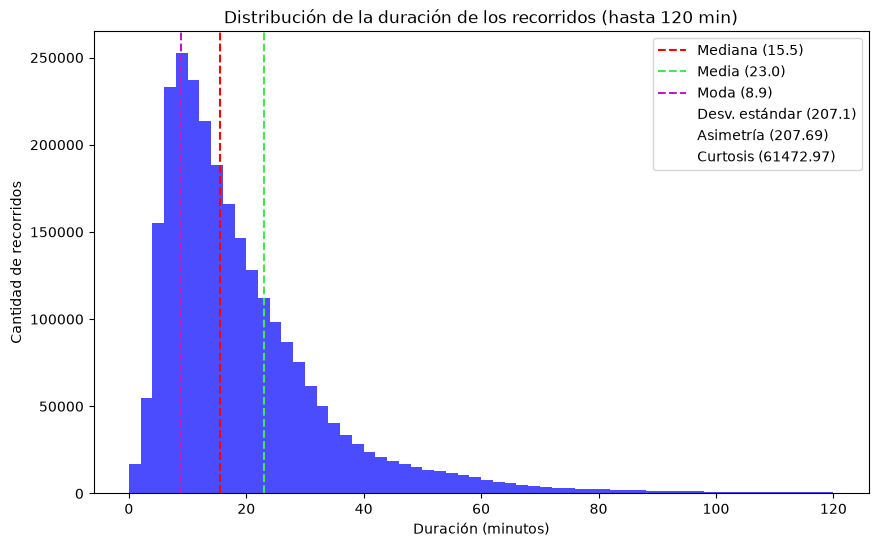

In [82]:
# se grafica hasta 120 min, esto de sebe a que hay valures muy grandes de recorrido (outliers)
# que hacen que el grafico que inilegible cuando se incluyen
limite_min = 120

plot_histograma_estadisticos(
    df_recorridos['duracion_recorrido_min'],
    bins=60,
    rango=(0, limite_min),
    titulo=f'Distribución de la duración de los recorridos (hasta {limite_min} min)',
    xlabel='Duración (minutos)',
    ylabel='Cantidad de recorridos',
)


Vemos que la distribucion de recorridos es prfundamente asimétrica y aparentemente contine muchos outliers en la zona derecha.

In [83]:
# outliers (criterio del rango intercuartílico)
duracion = df_recorridos['duracion_recorrido_min']
Q1 = duracion.quantile(0.25)
Q3 = duracion.quantile(0.75)
IQR = Q3 - Q1

# la duración no puede ser negativa, por lo que el límite inferior se acota en 0
limite_inferior = max(0, Q1 - 1.5 * IQR)
limite_superior = Q3 + 1.5 * IQR

limite_inferior_count = (duracion < limite_inferior).sum()
limite_superior_count = (duracion > limite_superior).sum()

print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"Cantidad de recorridos por debajo del límite inferior ({limite_inferior:.2f} min): {limite_inferior_count:,}")
print(f"Cantidad de recorridos por encima del límite superior ({limite_superior:.2f} min): {limite_superior_count:,}")
print(f"Porcentaje de recorridos por debajo del límite inferior: {limite_inferior_count / len(duracion) * 100:.2f}%")
print(f"Porcentaje de recorridos por encima del límite superior: {limite_superior_count / len(duracion) * 100:.2f}%")



Q1: 9.53, Q3: 25.22, IQR: 15.68
Cantidad de recorridos por debajo del límite inferior (0.00 min): 0
Cantidad de recorridos por encima del límite superior (48.74 min): 156,752
Porcentaje de recorridos por debajo del límite inferior: 0.00%
Porcentaje de recorridos por encima del límite superior: 5.98%


In [84]:
print("cantidad de recorridos por encima de 240 minutos: ", (duracion > 120).sum())

cantidad de recorridos por encima de 240 minutos:  19565


Usuarios distintos con al menos un viaje: 212,068


count    212068.0
mean         12.0
std          32.0
min           1.0
25%           1.0
50%           3.0
75%           8.0
max        1122.0
Name: viajes_por_usuario, dtype: float64

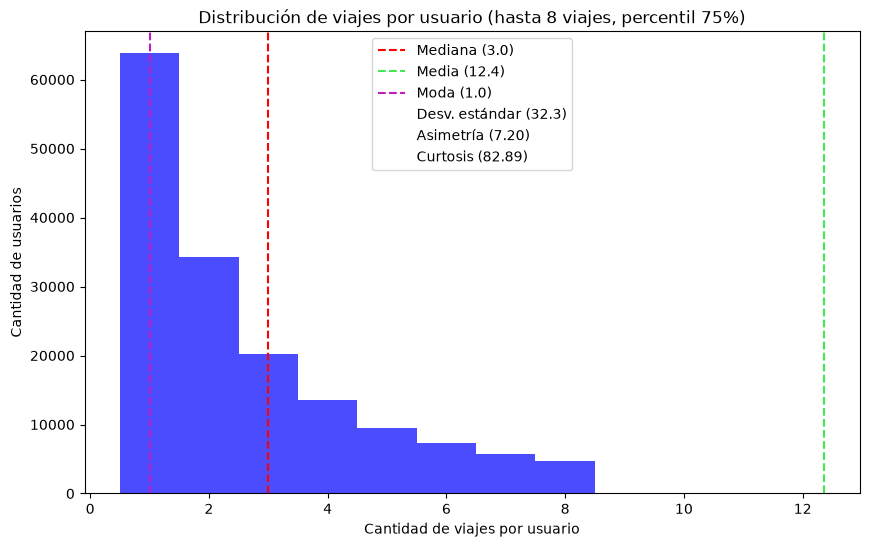

In [85]:
# --- A. Cuantitativa discreta (derivada): cantidad de viajes por usuario ---
viajes_por_usuario = df_recorridos.groupby("id_usuario", observed=True).size().rename("viajes_por_usuario")

print(f"Usuarios distintos con al menos un viaje: {viajes_por_usuario.shape[0]:,}")
display(viajes_por_usuario.describe().round())

# la distribucion es muy asimetrica (max = 1122), se grafica hasta el percentil 75
# para que el grafico sea legible
percentil = 0.75
limite_viajes = int(viajes_por_usuario.quantile(percentil))

plot_histograma_estadisticos(
    viajes_por_usuario,
    bins=limite_viajes,
    rango=(0.5, limite_viajes + 0.5),
    titulo=f'Distribución de viajes por usuario (hasta {limite_viajes} viajes, percentil {percentil:.0%})',
    xlabel='Cantidad de viajes por usuario',
    ylabel='Cantidad de usuarios',
)


Se observa que la distribución de cantidad de viajes por usuario es también muy asimétrica.

### Analisis de estaciones y combinaciones

In [86]:
estacion_recorridos_counter = df_recorridos.groupby("id_estacion_origen", observed=True).size().rename("recorridos_por_estacion").sort_values(ascending=False)
diez_estaciones_mas_recorridos = estacion_recorridos_counter.head(10)

print("Cantidad de estaciones distintas:", estacion_recorridos_counter.shape[0])

print("Estaciones con mas recorridos:")
for estacion in diez_estaciones_mas_recorridos.index:
    count = diez_estaciones_mas_recorridos[estacion]
    print(f"{estacion}: {count} recorridos ({count/estacion_recorridos_counter.sum() * 100:.2f}%)")

Cantidad de estaciones distintas: 364
Estaciones con mas recorridos:
175BAEcobici: 35834 recorridos (1.37%)
14BAEcobici: 31698 recorridos (1.21%)
8BAEcobici: 27249 recorridos (1.04%)
5BAEcobici: 24924 recorridos (0.95%)
202BAEcobici: 22779 recorridos (0.87%)
130BAEcobici: 22213 recorridos (0.85%)
54BAEcobici: 21812 recorridos (0.83%)
289BAEcobici: 21660 recorridos (0.83%)
128BAEcobici: 21034 recorridos (0.80%)
152BAEcobici: 20914 recorridos (0.80%)


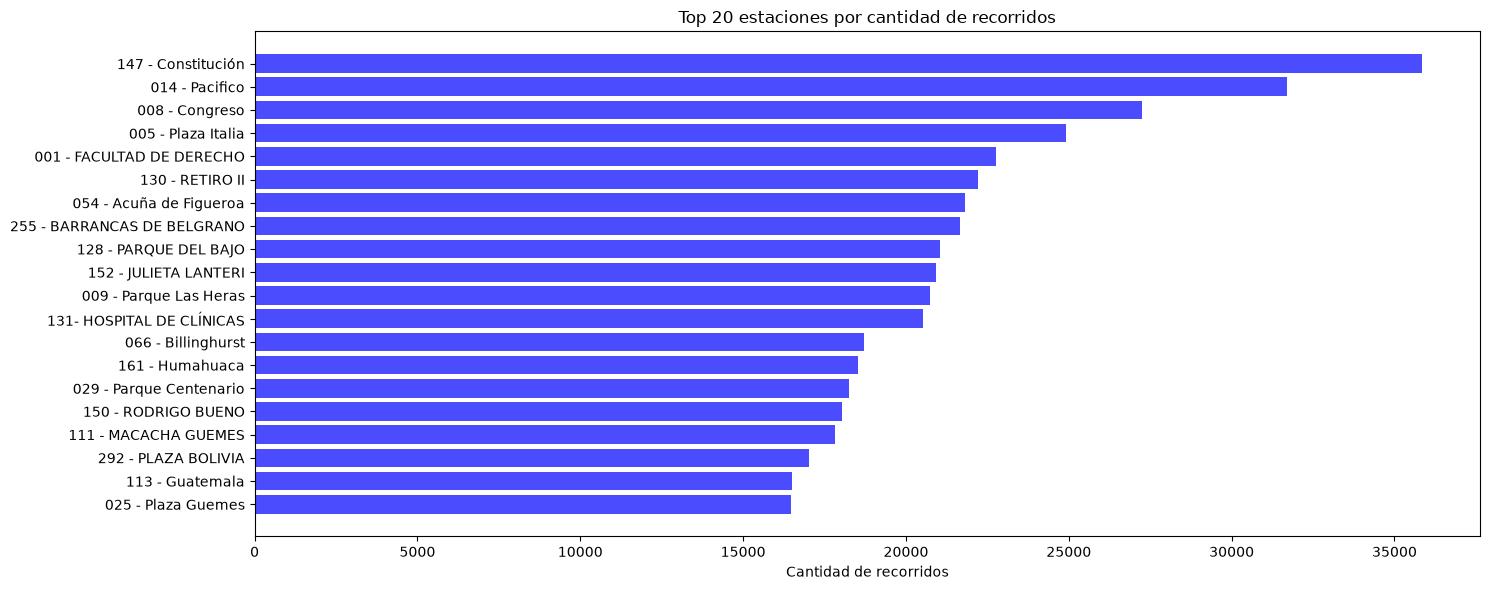

In [114]:
# Graficamos la cantidad de recorridos por estación de origen (top 20)
top_n = 20
top_estaciones = estacion_recorridos_counter.head(top_n)
# se usa el nombre de la estacion en vez del id para que sea legible
nombres = (
    df_recorridos.drop_duplicates("id_estacion_origen")
    .set_index("id_estacion_origen")["nombre_estacion_origen"]
    .astype(str)
)

fig, ax = plt.subplots(figsize=(15, 6))

ax.barh(top_estaciones.index.map(nombres)[::-1], top_estaciones.values[::-1], color="blue", alpha=0.7)
ax.set_title(f"Top {top_n} estaciones por cantidad de recorridos")
ax.set_xlabel("Cantidad de recorridos")

plt.tight_layout()
plt.show()

In [ ]:
combinaciones_estaciones_counter = df_recorridos.groupby(["id_estacion_origen", "id_estacion_destino"], observed=True).size().rename("recorridos_por_combinacion").sort_values(ascending=False)

print("Cantidad de combinaciones distintas de estaciones:", combinaciones_estaciones_counter.shape[0])
print("Combinaciones de estaciones con mas recorridos:")
for (origen, destino), count in combinaciones_estaciones_counter.head(10).items():
    print(f"{origen} -> {destino}: {count} recorridos ({count/combinaciones_estaciones_counter.sum() * 100:.2f}%)")


Cantidad de combinaciones distintas de estaciones: 77380
Combinaciones de estaciones con mas recorridos:
152BAEcobici -> 152BAEcobici: 4046 recorridos (0.15%)
5BAEcobici -> 5BAEcobici: 2439 recorridos (0.09%)
14BAEcobici -> 14BAEcobici: 2391 recorridos (0.09%)
379BAEcobici -> 379BAEcobici: 2345 recorridos (0.09%)
14BAEcobici -> 239BAEcobici: 2178 recorridos (0.08%)
458BAEcobici -> 458BAEcobici: 2086 recorridos (0.08%)
242BAEcobici -> 202BAEcobici: 2050 recorridos (0.08%)
202BAEcobici -> 202BAEcobici: 2033 recorridos (0.08%)
210BAEcobici -> 210BAEcobici: 2019 recorridos (0.08%)
448BAEcobici -> 130BAEcobici: 2015 recorridos (0.08%)


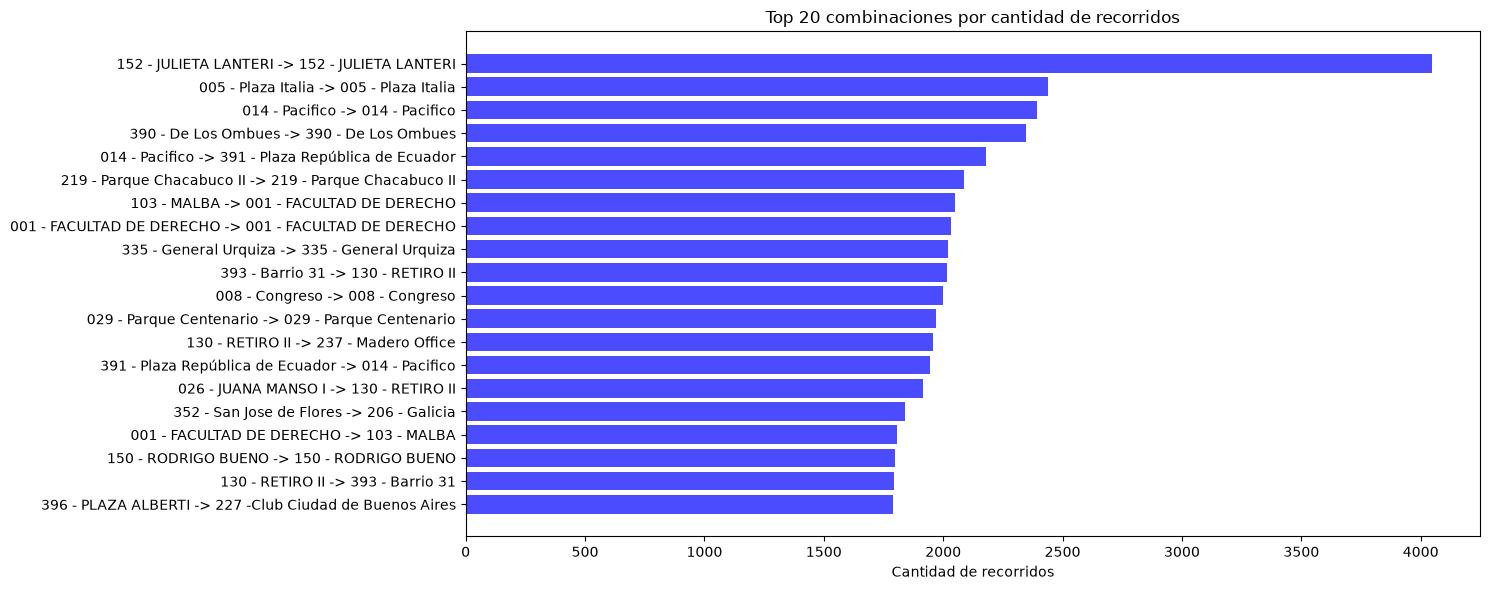

In [100]:
# Graficamos la cantidad de recorridos por combinación origen -> destino (top 20)
top_n = 20
top_combinaciones = combinaciones_estaciones_counter.head(top_n)
# etiqueta "origen -> destino" con nombres (reutiliza `nombres` de la celda anterior)
# algunas estaciones solo aparecen como destino, en ese caso se usa el id
etiquetas = [f"{nombres.get(origen, origen)} -> {nombres.get(destino, destino)}" for origen, destino in top_combinaciones.index]

fig, ax = plt.subplots(figsize=(15, 6))

ax.barh(etiquetas[::-1], top_combinaciones.values[::-1], color="blue", alpha=0.7)
ax.set_title(f"Top {top_n} combinaciones por cantidad de recorridos")
ax.set_xlabel("Cantidad de recorridos")

plt.tight_layout()
plt.show()

In [ ]:
# calcular porcentaje de recorridos circulares (origen = destino)
# origen y destino son categóricas con categorías distintas, por lo que se comparan como texto
es_circular = df_recorridos["id_estacion_origen"].astype(str) == df_recorridos["id_estacion_destino"].astype(str)
recorridos_circulares = df_recorridos[es_circular]
porcentaje_circulares = len(recorridos_circulares) / len(df_recorridos) * 100
print(f"Porcentaje de recorridos circulares (origen = destino): {porcentaje_circulares:.2f}% ({len(recorridos_circulares):,} recorridos)")

print(f"Percentaja que representa el top 20 con respecto al total de recorridos: {top_combinaciones.sum() / len(df_recorridos) * 100:.2f}% ({top_combinaciones.sum():,} recorridos)")

Porcentaje de recorridos circulares (origen = destino): 6.80% (178,244 recorridos)
Percentaja que representa el top 20 con respecto al total de recorridos: 1.62% (42,424 recorridos)


Dato curioso observado en combinaciones: 10 de las 20 combinaciones más frecuentes son circulares (origen = destino); sin embargo, el total de recorridos circulares representa solo el 6.8% del total de recorridos.

## Creación de variables

#### Recorridos - crear columna para clasificar duracion

In [90]:
# --- B. Categórica ordinal (derivada): duración agrupada con orden explícito ---
etiquetas_duracion = ["corto", "medio", "largo"]
orden_duracion = CategoricalDtype(categories=etiquetas_duracion, ordered=True)

corto_threshold = df_recorridos["duracion_recorrido_min"].quantile(1 / 3)   # corto:  hasta el primer tercil
medio_threshold = df_recorridos["duracion_recorrido_min"].quantile(2 / 3)   # medio:  hasta el segundo tercil
largo_threshold = float("inf")                                              # largo:  por encima del segundo tercil

print(f"Umbrales: corto <= {corto_threshold:.1f} min | medio <= {medio_threshold:.1f} min | largo > {medio_threshold:.1f} min")

df_recorridos["duracion_categoria"] = pd.cut(
    df_recorridos["duracion_recorrido_min"],
    bins=[-1, corto_threshold, medio_threshold, largo_threshold],
    labels=etiquetas_duracion,
).astype(orden_duracion)

df_recorridos["duracion_categoria"].value_counts().sort_index()


Umbrales: corto <= 11.3 min | medio <= 21.3 min | largo > 21.3 min


duracion_categoria
corto    874828
medio    874385
largo    873116
Name: count, dtype: int64

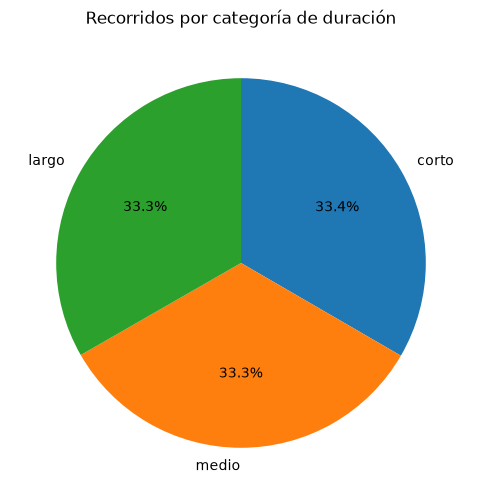

In [91]:
conteo_duracion = df_recorridos["duracion_categoria"].value_counts().sort_index()   # orden: corto, medio, largo

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(conteo_duracion.values, labels=conteo_duracion.index,
       autopct="%1.1f%%", startangle=90, counterclock=False)
ax.set_title("Recorridos por categoría de duración")
plt.show()

#### Vriables dervadas de la fecha

In [92]:
# hora, dia y mes de inicio del viaje como numeros (no modifica fecha_origen_recorrido)
df_recorridos["hora_inicio"] = df_recorridos["fecha_origen_recorrido"].dt.hour    # 0-23
df_recorridos["dia_inicio"] = df_recorridos["fecha_origen_recorrido"].dt.dayofweek  # 0-6 (0 = lunes, 6 = domingo)
df_recorridos["mes_inicio"] = df_recorridos["fecha_origen_recorrido"].dt.month    # 1-12

In [93]:
df_recorridos[["Id_recorrido", "hora_inicio", "dia_inicio", "mes_inicio"]].head()

,Id_recorrido,hora_inicio,dia_inicio,mes_inicio
0,17910696BAEcobici,10,0,4
1,17600256BAEcobici,17,2,3
2,17255670BAEcobici,23,2,2
3,17996972BAEcobici,11,2,5
4,17148836BAEcobici,6,0,2


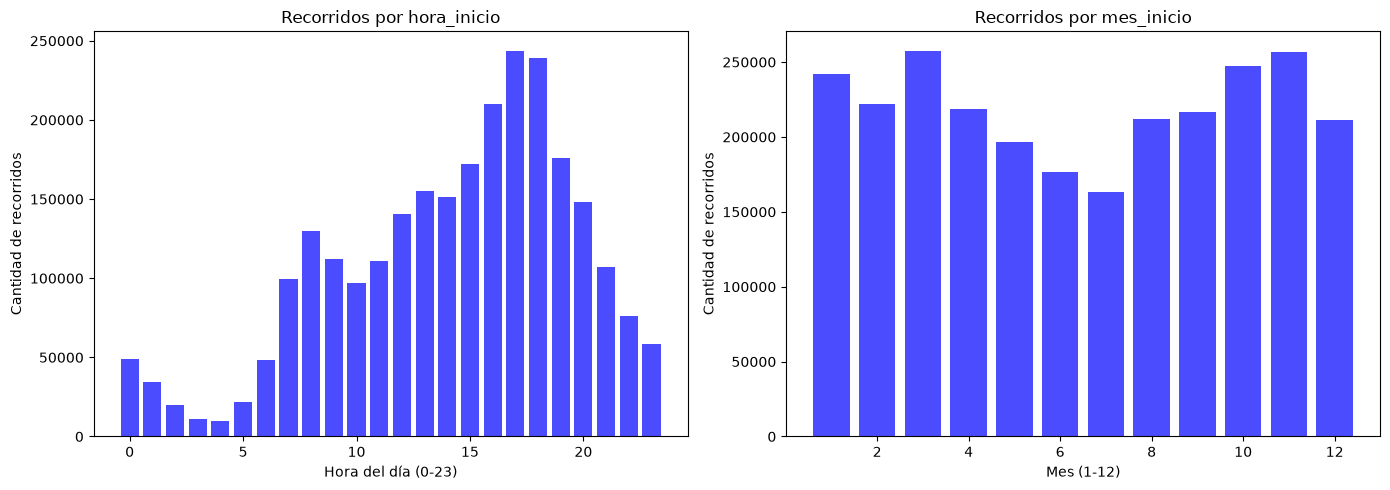

In [94]:
# creat un plot para ver como se distribuye"hora_inicio", "dia_inicio", "mes_inicio"
# barplots: cantidad de recorridos por hora y por mes
variables_bar = {
    "hora_inicio": "Hora del día (0-23)",
    "mes_inicio": "Mes (1-12)",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (columna, etiqueta) in zip(axes, variables_bar.items()):
    conteo = df_recorridos[columna].value_counts().sort_index()   # cantidad de recorridos por valor
    ax.bar(conteo.index, conteo.values, color="blue", alpha=0.7)
    ax.set_title(f"Recorridos por {columna}")
    ax.set_xlabel(etiqueta)
    ax.set_ylabel("Cantidad de recorridos")
plt.tight_layout()
plt.show()

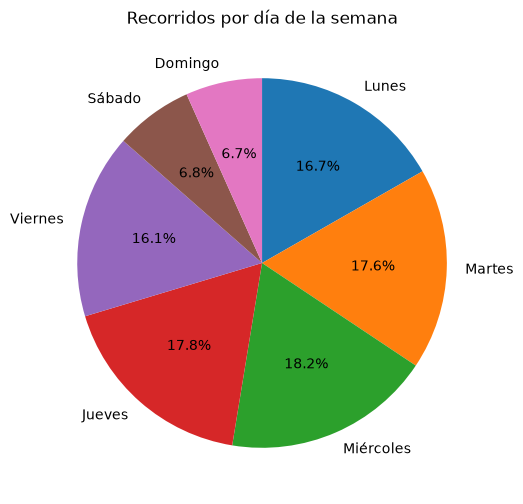

In [95]:
# pie chart: porcentaje de recorridos por día de la semana
nombres_dias = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
conteo_dias = df_recorridos["dia_inicio"].value_counts().sort_index()   # 0 = lunes, 6 = domingo

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(conteo_dias.values, labels=[nombres_dias[d] for d in conteo_dias.index],
       autopct="%1.1f%%", startangle=90, counterclock=False)
ax.set_title("Recorridos por día de la semana")
plt.show()

#### Categóricas nominales: frecuencia de cada categoría



--- genero ---
genero
MALE      60.54
FEMALE    30.29
OTHER      9.17
Name: proportion, dtype: float64

--- modelo_bicicleta ---
modelo_bicicleta
FIT       63.12
ICONIC    36.88
Name: proportion, dtype: float64


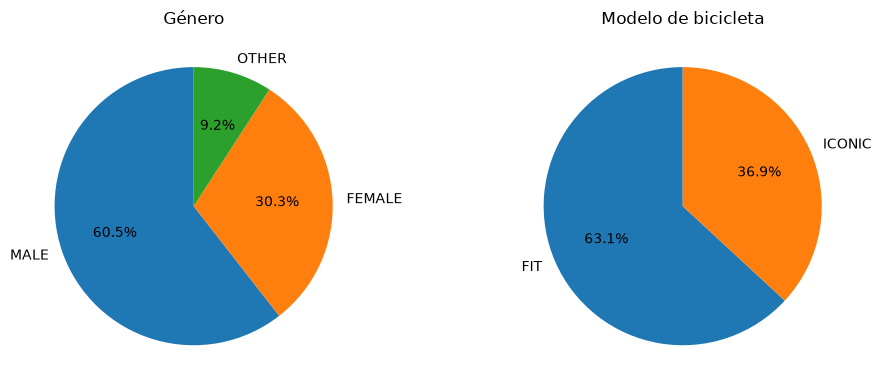

In [96]:
for col in ["genero", "modelo_bicicleta"]:
    print(f"\n--- {col} ---")
    print((df_recorridos[col].value_counts(normalize=True) * 100).round(2))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
genero_counts = df_recorridos["genero"].value_counts()
modelo_counts = df_recorridos["modelo_bicicleta"].value_counts()
axes[0].pie(genero_counts, labels=genero_counts.index, autopct="%1.1f%%", startangle=90)
axes[0].set_title("Género")
axes[1].pie(modelo_counts, labels=modelo_counts.index, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Modelo de bicicleta")
plt.tight_layout()
plt.show()


In [97]:
df_recorridos.head(5)

,Id_recorrido,duracion_recorrido_min,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,...,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,genero,usuario_2023,duracion_categoria,hora_inicio,dia_inicio,mes_inicio
0,17910696BAEcobici,30.800000,2023-04-24 10:30:10,358BAEcobici,249 - Balbín,2519 Conesa,-58.465586,-34.561486,2023-04-24 11:00:58,278BAEcobici,...,-58.469813,-34.564122,861866BAEcobici,ICONIC,MALE,False,largo,10,0,4
1,17600256BAEcobici,4.800000,2023-03-22 17:40:55,444BAEcobici,061 - Ministerio de Economia,"Balcarce e Yrigoyen, Hipolito Av.",-58.370716,-34.608936,2023-03-22 17:45:43,3BAEcobici,...,-58.368174,-34.611102,217525BAEcobici,ICONIC,FEMALE,False,corto,17,2,3
2,17255670BAEcobici,18.383333,2023-02-15 23:12:22,280BAEcobici,222 - SIMON BOLIVAR,"1701 Fernandez Moreno, Baldomero",-58.449379,-34.633528,2023-02-15 23:30:45,280BAEcobici,...,-58.449379,-34.633528,954201BAEcobici,ICONIC,MALE,True,medio,23,2,2
3,17996972BAEcobici,19.416667,2023-05-03 11:00:20,273BAEcobici,223 - GAINZA,"494 Gainza, Martin De, Gral.",-58.446751,-34.616758,2023-05-03 11:19:45,367BAEcobici,...,-58.477209,-34.616212,179414BAEcobici,ICONIC,MALE,False,medio,11,2,5
4,17148836BAEcobici,6.300000,2023-02-06 06:50:58,65BAEcobici,065 - Julián Álvarez,3822 Guemes,-58.415787,-34.587312,2023-02-06 06:57:16,14BAEcobici,...,-58.426387,-34.577424,8098BAEcobici,ICONIC,MALE,False,corto,6,0,2


## Medidas de asociacion


Medimos el grado de asociación entre las variables relevantes para el problema de ML (la duración del recorrido y sus posibles predictoras). La medida depende del **tipo de las dos variables**:

| Tipos | Medida |
| --- | --- |
| Numérica - numérica | Pearson |
| Numérica - nominal (3 o más categorías) | Eta cuadrado |
| Numérica - binaria | Correlación punto-biserial |
| Ordinal - numérica / binaria | Kendall Tau (sobre una muestra de 100.000 filas por costo computacional) |
| Ordinal - nominal / Nominal - binaria | Cramér's V |
| Binaria - binaria | Coeficiente Phi |

Variables: `duracion_recorrido_min` (numérica), `duracion_categoria` (ordinal), `hora_inicio`, `dia_inicio` y `mes_inicio` (numéricas), `genero` (nominal), `modelo_bicicleta` y `usuario_nuevo` (binarias).

In [98]:
from scipy.stats import chi2_contingency,f_oneway

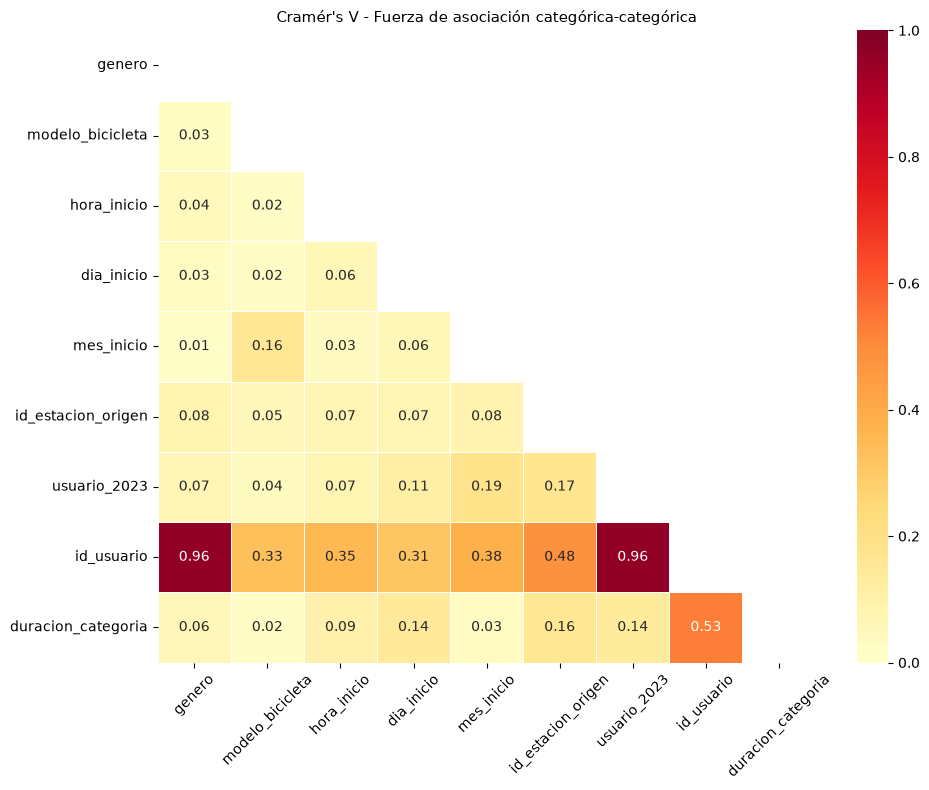

In [99]:
# Funcioncita para calcular Cramér's V entre dos variables categóricas x e y
def cramers_v(x, y):
    xc, _ = pd.factorize(x)
    yc, _ = pd.factorize(y)
    r, k, n = xc.max() + 1, yc.max() + 1, len(xc)

    celdas, observado = np.unique(xc.astype(np.int64) * k + yc, return_counts=True)
    filas, columnas = celdas // k, celdas % k
    fila_total = np.bincount(xc, minlength=r)
    col_total = np.bincount(yc, minlength=k)

    esperado = fila_total[filas] * col_total[columnas] / n
    # las celdas sin observaciones aportan su valor esperado completo al chi2
    chi2 = ((observado - esperado) ** 2 / esperado).sum() + (n - esperado.sum())

    phi2 = max(0, chi2 / n - (k - 1) * (r - 1) / (n - 1))
    r_corr = r - (r - 1) ** 2 / (n - 1)
    k_corr = k - (k - 1) ** 2 / (n - 1)
    return np.sqrt(phi2 / min(k_corr - 1, r_corr - 1))

# calculamos fuerza entre variables categoricas

cols = ["genero", "modelo_bicicleta", "hora_inicio", "dia_inicio", "mes_inicio", "id_estacion_origen", "usuario_2023", "id_usuario", "duracion_categoria"]

v_mat = pd.DataFrame(index=cols, columns=cols, dtype=float)

for i, c1 in enumerate(cols):
    for c2 in cols[i:]:
        if c1 == c2:
            v_mat.loc[c1, c2] = 1.0
        else:
            validos = df_recorridos[c1].notna() & df_recorridos[c2].notna()
            v = cramers_v(df_recorridos.loc[validos, c1], df_recorridos.loc[validos, c2])
            # la matriz es simétrica: se calcula una sola vez
            v_mat.loc[c1, c2] = v
            v_mat.loc[c2, c1] = v


# Máscara para mostrar solo la mitad inferior de la matriz
mask = np.triu(np.ones_like(v_mat, dtype=bool))

# Dibujamos la matriz con heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(v_mat.astype(float), annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, linewidths=0.5,
            mask=mask, ax=ax)

ax.set_title("Cramér's V - Fuerza de asociación categórica-categórica", fontsize=11)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


Conclusiones de correlacion:

Podemos observar que la relación entre la duración del viaje es relativamente fuerte con el usuario solamente. Esto tiene sentido porque muchos usuarios deben tener el mismo recorrido todos los dias (por ejemplo, para ir al trabajo).

Con repecto a la correlación obeservada para la categoria `id_usuario` no es representativo, ya que estas son relaciones que nos nos interesan para resolver el problema planteado.

### Split del dataset

## Análisis de outliers
